# 02. Two-box ocean model  
# 手を動かして学ぶ 2-box 海洋炭素循環モデル  
# Hands-on two-box ocean carbon-cycle model

この Notebook は、**説明 → 予想 → 実行 → 図 → 考察** の順で進みます。  
This notebook follows the sequence: **explanation → prediction → execution → plot → interpretation**.

## 今日の目標 / Goals

1. 表層ボックス S と深層ボックス D の意味を理解する。  
   Understand the meaning of the surface box S and deep box D.

2. 保存則を Python の式として書く。  
   Write conservation laws as Python expressions.

3. 1 日だけ進める計算と、長時間積分の違いを理解する。  
   Understand the difference between one-day stepping and long-time integration.

4. パラメタを変えて、モデル応答を見る。  
   Change parameters and examine model responses.

5. `state` は「概念」ではなく、**たくさんの変数をまとめて持つための入れ物**として使う。  
   Treat `state` not as a special concept, but simply as **a container for many variables**.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

plt.rcParams["figure.figsize"] = (7, 4)

## 1. まず絵で考える / First, think with a diagram

現実の海洋は複雑ですが、ここでは海を 2 つの箱に分けます。  
The real ocean is complex, but here we divide it into two boxes.

```text
Atmosphere
   ↑↓ CO2 exchange

Surface ocean (S)
   ↑↓ exchange FSD
Deep ocean (D)
```

この単純化で表現したいのは次の過程です。  
This simplification is meant to represent the following processes.

- 表層での生物生産  
  biological production in the surface ocean

- 有機物の深層への輸送  
  export of organic matter to the deep ocean

- 深層での再無機化  
  remineralization in the deep ocean

- 表層と深層の交換  
  exchange between surface and deep ocean

- 大気海洋 CO2 交換  
  air-sea CO2 exchange

**プログラム上の対応 / Programming correspondence**

```text
Surface PO4  →  PO4S
Deep PO4     →  PO4D
Surface DIC  →  DICS
Deep DIC     →  DICD
```

名前の最後の `S` は Surface、`D` は Deep です。  
The final `S` means Surface, and `D` means Deep.

In [ ]:
CV1 = 1.0250e3
CV2 = 9.7561e-4
CV3 = 1.0e6
CV4 = 3.1536e7
CV5 = 8.64e4

def to_umolkg(x):
    return CV2 * 1.0e6 * x

def to_ppmv(x):
    return CV3 * x

def o2sat(TEM, SAL):
    N1 = -1.734292e2
    N2 = +2.496339e2
    N3 = +1.433483e2
    N4 = -2.184920e1
    N5 = -3.309600e-2
    N6 = +1.425900e-2
    N7 = -1.700000e-3
    ATEM = TEM + 273.15
    O2S = math.exp(
        N1 + N2 * 1.0e2 / ATEM
        + N3 * math.log(ATEM / 1.0e2)
        + N4 * ATEM / 1.0e2
        + SAL * (N5 + N6 * ATEM / 1.0e2 + N7 * (ATEM / 1.0e2) ** 2)
    )
    return O2S * 4.35e1 * 1.025e-3

def chemeq_const(TEM, SAL):
    ATEM = TEM + 273.15
    TK = ATEM * 1.0e-2
    SK = 2.3517e-2 + (-2.3656e-2 + 4.7036e-3 * TK) * TK
    K0 = math.exp(-6.02409e1 + 9.34517e1 / TK + 2.33585e1 * math.log(TK) + SK * SAL)
    K1 = math.exp(math.log(10.0) * (
        13.7201 - 3.1334e-2 * ATEM - 3.23576e3 / ATEM
        - 1.3e-5 * SAL * ATEM + 1.032e-1 * math.sqrt(SAL)
    ))
    safe_sal = SAL if SAL > 0 else 1.0
    K2 = math.exp(math.log(10.0) * (
        -5.3719645e3 - 1.671221e0 * ATEM - 2.2913e-1 * SAL
        - 1.83802e1 * math.log10(safe_sal) + 1.2837528e5 / ATEM
        + 2.1943005e3 * math.log10(ATEM) + 8.0944e-4 * SAL * ATEM
        + 5.61711e3 * math.log10(safe_sal) / ATEM - 2.136e0 * SAL / ATEM
    ))
    KB = math.exp(math.log(10.0) * (-9.26 + 8.86e-3 * SAL + 1e-3 * TEM))
    KW = math.exp(
        +1.489802e2 - 1.384726e4 / ATEM - 2.36521e1 * math.log(ATEM)
        + ((-7.92447e1 + 3.29872e3 / ATEM + 1.20408e1 * math.log(ATEM))
           * math.sqrt(SAL) - 1.9813e-2 * SAL)
    )
    BT = 4.106e-4 * SAL / 35.0
    FH = 1.29e-2 - 2.4e-3 * ATEM + 4.61e-4 * SAL**2 - 1.48e-6 * ATEM * SAL**2
    return BT, K0, K1, K2, KB, KW, FH

def co2_nibun(BT, K0, K1, K2, KB, KW, AT, CT):
    ATX = CV2 * AT
    CTX = CV2 * CT
    HMIN = 1.0e-14
    HMAX = 1.0
    DELTA = 1.0e-15
    h_low = HMIN
    h_high = HMAX
    hx = 0.5 * (h_low + h_high)
    for _ in range(100000):
        h = 0.5 * (h_low + h_high)
        denom = h * h + K1 * h + K1 * K2
        at_calc = (
            (2.0 * K1 * K2 * CTX) / denom
            + (h * K1 * CTX) / denom
            + (KB * BT) / (h + KB)
            + KW / h
            - h
        )
        if abs(ATX - at_calc) <= DELTA:
            hx = h
            break
        if at_calc < ATX:
            h_high = h
        else:
            h_low = h
    denom2 = hx * hx + K1 * hx + K1 * K2
    PCO2 = (hx * hx * CTX) / denom2 / K0
    CO2 = (hx * hx * CTX) / denom2 / CV2
    HCO3 = K1 * CO2 / hx
    CO32 = K2 * HCO3 / hx
    return CO2, HCO3, CO32, PCO2

def carbonate_box(temp, sal, alk, dic):
    BT, K0, K1, K2, KB, KW, FH = chemeq_const(temp, sal)
    CO2, HCO3, CO32, PCO2 = co2_nibun(BT, K0, K1, K2, KB, KW, alk, dic)
    return {
        "BT": BT, "K0": K0, "K1": K1, "K2": K2,
        "KB": KB, "KW": KW, "CO2": CO2, "HCO3": HCO3,
        "CO32": CO32, "PCO2": PCO2
    }

## 2. ボックスの大きさを決める / Define box sizes

表層ボックスの体積は、

```text
海洋面積 × 表層の厚さ
```

で決まります。  
The surface-box volume is:

```text
ocean area × surface thickness
```

深層ボックスは、全海洋体積から表層体積を引いた残りです。  
The deep box is the remaining volume after subtracting the surface box from the total ocean volume.

このセルでは、まず数字の大きさに慣れることが目的です。  
The goal of this cell is to get used to the scale of the numbers.

In [ ]:
VOCN = 1.292e18
AOCN = 3.49e14
VATM = 1.773e20
ZOCNS = 250.0

VOCNS = AOCN * ZOCNS
VOCND = VOCN - VOCNS

pd.DataFrame({
    "Box": ["Surface (S)", "Deep (D)"],
    "Volume [m3]": [VOCNS, VOCND],
    "Fraction": [VOCNS / VOCN, VOCND / VOCN],
})

,Box,Volume [m3],Fraction
0,Surface (S),8.725000e+16,0.067531
1,Deep (D),1.204750e+18,0.932469


### Mini exercise 1 / ミニ演習 1

`ZOCNS` を 100 m, 250 m, 500 m に変えると、表層体積の割合はどう変わるでしょうか。  
Change `ZOCNS` to 100 m, 250 m, and 500 m. How does the surface volume fraction change?

**考えるポイント / Point to think about**

表層の厚さを厚くすると、表層ボックスの体積は線形に増えます。  
If the surface layer becomes thicker, the surface-box volume increases linearly.

In [ ]:
for z in [100, 250, 500]:
    vocns = AOCN * z
    print(f"ZOCNS = {z:4.0f} m  surface fraction = {vocns / VOCN:.4f}")

ZOCNS =  100 m  surface fraction = 0.0270
ZOCNS =  250 m  surface fraction = 0.0675
ZOCNS =  500 m  surface fraction = 0.1351


## 3. 初期値を入れる / Set initial values

まずは普通の Python 変数として値を入れます。  
First, we store values as ordinary Python variables.

ここでは `state` をまだ使いません。  
We do not use `state` yet.

理由は単純です。最初は、

```python
PO4S = ...
PO4D = ...
```

のように書いた方が、何を計算しているかが見えやすいからです。  
This is because writing variables explicitly makes it easier to see what is being calculated.

**単位 / Units**

入力値は `mol/kg` で与え、モデル内部では `mol/m3` に変換します。  
Input values are given in `mol/kg`, and converted internally to `mol/m3`.

In [ ]:
TEMS = 20.0
TEMD = 2.0
SALS = 34.7
SALD = 34.7

PO4S = 2.20e-6 * CV1
PO4D = 2.20e-6 * CV1
DICS = 2.258e-3 * CV1
DICD = 2.258e-3 * CV1
ALKS = 2.371e-3 * CV1
ALKD = 2.371e-3 * CV1
DO2S = 1.70e-4 * CV1
DO2D = 1.70e-4 * CV1
PCO2A = 280.0 / CV3

pd.DataFrame({
    "Quantity": ["PO4", "DIC", "ALK", "O2"],
    "Surface S": [to_umolkg(PO4S), to_umolkg(DICS), to_umolkg(ALKS), to_umolkg(DO2S)],
    "Deep D": [to_umolkg(PO4D), to_umolkg(DICD), to_umolkg(ALKD), to_umolkg(DO2D)],
    "Unit": ["umol/kg", "umol/kg", "ueq/kg", "umol/kg"],
})

,Quantity,Surface S,Deep D,Unit
0,PO4,2.200001,2.200001,umol/kg
1,DIC,2258.000565,2258.000565,umol/kg
2,ALK,2371.000593,2371.000593,ueq/kg
3,O2,170.000043,170.000043,umol/kg


## 4. 炭酸系を一度だけ計算する / Compute carbonate chemistry once

DIC と ALK から pCO2 を計算します。  
We compute pCO2 from DIC and ALK.

この Notebook では炭酸系の細かい導出には入りません。  
In this notebook, we do not derive carbonate chemistry in detail.

ここでは関数 `carbonate_box()` を、

```text
temperature, salinity, alkalinity, DIC
↓
pCO2 and carbonate species
```

を返す装置として使います。  
Here, `carbonate_box()` is used as a device that returns pCO2 and carbonate species from temperature, salinity, alkalinity, and DIC.

In [ ]:
carbS = carbonate_box(TEMS, SALS, ALKS, DICS)
carbD = carbonate_box(TEMD, SALD, ALKD, DICD)

print("Surface pCO2 [ppmv] =", to_ppmv(carbS["PCO2"]))
print("Deep pCO2    [ppmv] =", to_ppmv(carbD["PCO2"]))

Surface pCO2 [ppmv] = 895.6683140329088
Deep pCO2    [ppmv] = 463.60558910702343


## 5. 1 日だけ進める / Advance the model by one day

いきなり 3000 年積分せず、まず 1 日だけ進めます。  
Before running a 3000-year simulation, we advance the model by only one day.

### PO4 の保存則 / Conservation law for PO4

表層 PO4 は、

```text
深層から入る量 − 生物ポンプで出ていく量
```

で変わります。  
Surface PO4 changes by:

```text
input from the deep box − removal by biological export
```

Python では、この形が

```python
PO4SX = PO4S + (...)
```

になります。ここで `X` は「次の値」を意味します。  
In Python this becomes `PO4SX = PO4S + (...)`. Here `X` means the next value.

In [ ]:
DT = 8.64e4
TRAN = 0.0
FSD = 4.096e7

RCP = 106.0
RNP = 16.0
RRC = 0.288
RO2P = 172.0

CEPS = 0.611
EPS = (CEPS / RCP) * AOCN / CV4

PO4SX = PO4S + (((TRAN + FSD) * (PO4D - PO4S) - EPS) * (DT / VOCNS))
PO4DX = PO4D + (((TRAN + FSD) * (PO4S - PO4D) + EPS) * (DT / VOCND))

print("PO4S old/new [umol/kg]", to_umolkg(PO4S), to_umolkg(PO4SX))
print("PO4D old/new [umol/kg]", to_umolkg(PO4D), to_umolkg(PO4DX))

PO4S old/new [umol/kg] 2.20000055 2.1999389219090206
PO4D old/new [umol/kg] 2.20000055 2.200005013208913


### Mini exercise 2 / ミニ演習 2

`FSD = 0` にしたら、1 日後の PO4S はどうなるでしょうか。  
If `FSD = 0`, what happens to PO4S after one day?

**予想 / Prediction**

- 深層から PO4 が補給されない。  
  No PO4 is supplied from the deep box.

- 生物ポンプによる除去だけが残る。  
  Only removal by biological export remains.

実行する前に、PO4S が増えるか減るかを予想してください。  
Before running the cell, predict whether PO4S increases or decreases.

In [ ]:
FSD_test = 0.0
PO4SX_test = PO4S + (((TRAN + FSD_test) * (PO4D - PO4S) - EPS) * (DT / VOCNS))
print("FSD = 0 のとき")
print("PO4S old/new [umol/kg]", to_umolkg(PO4S), to_umolkg(PO4SX_test))

FSD = 0 のとき
PO4S old/new [umol/kg] 2.20000055 2.1999389219090206


## 6. DIC, ALK, O2 も同じように進める / Advance DIC, ALK, and O2 in the same way

基本形は PO4 と同じです。  
The basic structure is the same as for PO4.

```text
new value = old value + transport + biology + gas exchange
```

ただし、DIC, ALK, O2 は、生物ポンプに対する係数が違います。  
However, DIC, ALK, and O2 have different stoichiometric coefficients for biological processes.

- DIC は有機炭素と CaCO3 の影響を受ける。  
  DIC is affected by organic carbon and CaCO3.

- ALK は窒素・炭酸カルシウム過程の影響を受ける。  
  ALK is affected by nitrogen and calcium carbonate processes.

- O2 は有機物の生成・分解と逆向きに変化する。  
  O2 changes in the opposite direction to organic matter production and remineralization.

In [ ]:
alk_factor = 2.0 * RRC * RCP - RNP
dic_factor = (1.0 + RRC) * RCP

ALKSX = ALKS + (((TRAN + FSD) * (ALKD - ALKS) - alk_factor * EPS) * (DT / VOCNS))
ALKDX = ALKD + (((TRAN + FSD) * (ALKS - ALKD) + alk_factor * EPS) * (DT / VOCND))

DICSX = DICS + (((TRAN + FSD) * (DICD - DICS) - dic_factor * EPS) * (DT / VOCNS))
DICDX = DICD + (((TRAN + FSD) * (DICS - DICD) + dic_factor * EPS) * (DT / VOCND))

DO2SX = DO2S + (((TRAN + FSD) * (DO2D - DO2S) + RO2P * EPS) * (DT / VOCNS))
DO2DX = DO2D + (((TRAN + FSD) * (DO2S - DO2D) - RO2P * EPS) * (DT / VOCND))

pd.DataFrame({
    "Quantity": ["ALK S", "ALK D", "DIC S", "DIC D", "O2 S", "O2 D"],
    "Old": [to_umolkg(ALKS), to_umolkg(ALKD), to_umolkg(DICS), to_umolkg(DICD), to_umolkg(DO2S), to_umolkg(DO2D)],
    "New after 1 day": [to_umolkg(ALKSX), to_umolkg(ALKDX), to_umolkg(DICSX), to_umolkg(DICDX), to_umolkg(DO2SX), to_umolkg(DO2DX)],
})

,Quantity,Old,New after 1 day
0,ALK S,2371.000593,2370.997816
1,ALK D,2371.000593,2371.000794
2,DIC S,2258.000565,2257.992151
3,DIC D,2258.000565,2258.001174
4,O2 S,170.000043,170.010643
5,O2 D,170.000043,169.999275


## 7. 更新する / Update the variables

新しい値を計算しただけでは、モデルはまだ進んでいません。  
Computing new values alone does not advance the model.

次のように代入して初めて、現在値が 1 日後の値になります。  
Only after assignment do the current values become the values after one day.

```python
PO4S = PO4SX
PO4D = PO4DX
```

これは数値モデルで非常に重要です。  
This is extremely important in numerical models.

In [ ]:
PO4S = PO4SX
PO4D = PO4DX
ALKS = ALKSX
ALKD = ALKDX
DICS = DICSX
DICD = DICDX
DO2S = DO2SX
DO2D = DO2DX

print("Updated PO4S =", to_umolkg(PO4S), "umol/kg")

Updated PO4S = 2.1999389219090206 umol/kg


## 8. 関数にする / Put the update into a function

ここで初めて、値をまとめて渡すために辞書を使います。  
Now we use a dictionary to pass many values together.

ただし、`state` を大きな概念として扱う必要はありません。  
However, `state` does not need to be treated as a big concept.

ここでは単に、

```text
たくさんの変数をまとめた袋
```

です。  
Here it is simply:

```text
a bag containing many variables
```

関数 `one_step_two_box()` は、「現在の値」を受け取り、「1 日後の値」を返します。  
The function `one_step_two_box()` receives the current values and returns the values after one day.

In [ ]:
def initial_two_box():
    return {
        "PO4S": 2.20e-6 * CV1,
        "PO4D": 2.20e-6 * CV1,
        "ALKS": 2.371e-3 * CV1,
        "ALKD": 2.371e-3 * CV1,
        "DICS": 2.258e-3 * CV1,
        "DICD": 2.258e-3 * CV1,
        "DO2S": 1.70e-4 * CV1,
        "DO2D": 1.70e-4 * CV1,
        "PCO2A": 280.0 / CV3,
    }

def one_step_two_box(x, FSD=4.096e7, CEPS=0.611, air_sea=False):
    DT = 8.64e4
    TRAN = 0.0
    RCP = 106.0
    RNP = 16.0
    RRC = 0.288
    RO2P = 172.0
    EPS = (CEPS / RCP) * AOCN / CV4
    FAS = 3.0 * AOCN / CV5

    alk_factor = 2.0 * RRC * RCP - RNP
    dic_factor = (1.0 + RRC) * RCP

    carbS = carbonate_box(20.0, 34.7, x["ALKS"], x["DICS"])
    K0S = carbS["K0"]
    PCO2S = carbS["PCO2"]

    y = dict(x)

    y["PO4S"] = x["PO4S"] + (((TRAN + FSD) * (x["PO4D"] - x["PO4S"]) - EPS) * (DT / VOCNS))
    y["PO4D"] = x["PO4D"] + (((TRAN + FSD) * (x["PO4S"] - x["PO4D"]) + EPS) * (DT / VOCND))

    y["ALKS"] = x["ALKS"] + (((TRAN + FSD) * (x["ALKD"] - x["ALKS"]) - alk_factor * EPS) * (DT / VOCNS))
    y["ALKD"] = x["ALKD"] + (((TRAN + FSD) * (x["ALKS"] - x["ALKD"]) + alk_factor * EPS) * (DT / VOCND))

    gas_flux = 0.0
    if air_sea:
        gas_flux = FAS * CV1 * K0S * (x["PCO2A"] - PCO2S)

    y["DICS"] = x["DICS"] + (((TRAN + FSD) * (x["DICD"] - x["DICS"]) - dic_factor * EPS + gas_flux) * (DT / VOCNS))
    y["DICD"] = x["DICD"] + (((TRAN + FSD) * (x["DICS"] - x["DICD"]) + dic_factor * EPS) * (DT / VOCND))

    y["DO2S"] = x["DO2S"] + (((TRAN + FSD) * (x["DO2D"] - x["DO2S"]) + RO2P * EPS) * (DT / VOCNS))
    y["DO2D"] = x["DO2D"] + (((TRAN + FSD) * (x["DO2S"] - x["DO2D"]) - RO2P * EPS) * (DT / VOCND))

    if air_sea:
        carbS_new = carbonate_box(20.0, 34.7, y["ALKS"], y["DICS"])
        y["PCO2A"] = x["PCO2A"] + (FAS * CV1 * carbS_new["K0"] * (carbS_new["PCO2"] - x["PCO2A"])) * (DT / VATM)
    else:
        y["PCO2A"] = x["PCO2A"]

    return y

## 9. 3000 年まわす / Run for 3000 years

`one_step_two_box()` を for 文で何度も呼び出します。  
We call `one_step_two_box()` many times using a for-loop.

これが時間積分です。  
This is time integration.

```text
initial state
↓
after 1 day
↓
after 2 days
↓
...
↓
after 3000 years
```

1 年ごとに値を保存して、あとで図にします。  
We save the values once per year and plot them later.

In [ ]:
def run_two_box(years=3000, FSD=4.096e7, CEPS=0.611, air_sea=False):
    x = initial_two_box()
    history = []

    for day in range(years * 365 + 1):
        if day % 365 == 0:
            carbS = carbonate_box(20.0, 34.7, x["ALKS"], x["DICS"])
            carbD = carbonate_box(2.0, 34.7, x["ALKD"], x["DICD"])
            history.append({
                "year": day / 365,
                "PO4S": to_umolkg(x["PO4S"]),
                "PO4D": to_umolkg(x["PO4D"]),
                "DICS": to_umolkg(x["DICS"]),
                "DICD": to_umolkg(x["DICD"]),
                "ALKS": to_umolkg(x["ALKS"]),
                "ALKD": to_umolkg(x["ALKD"]),
                "DO2S": to_umolkg(x["DO2S"]),
                "DO2D": to_umolkg(x["DO2D"]),
                "PCO2S": to_ppmv(carbS["PCO2"]),
                "PCO2D": to_ppmv(carbD["PCO2"]),
                "PCO2A": to_ppmv(x["PCO2A"]),
            })
        x = one_step_two_box(x, FSD=FSD, CEPS=CEPS, air_sea=air_sea)

    return x, pd.DataFrame(history)

final, hist = run_two_box(years=3000, air_sea=False)
hist.tail()

,year,PO4S,PO4D,DICS,DICD,ALKS,ALKD,DO2S,DO2D,PCO2S,PCO2D,PCO2A
2996,2996.0,0.783213,2.302607,2064.569327,2272.009177,2307.165791,2375.623615,413.687585,152.351785,390.380961,497.170416,280.0
2997,2997.0,0.783213,2.302607,2064.569327,2272.009177,2307.165791,2375.623615,413.687585,152.351785,390.380961,497.170416,280.0
2998,2998.0,0.783213,2.302607,2064.569327,2272.009177,2307.165791,2375.623615,413.687585,152.351785,390.380961,497.170416,280.0
2999,2999.0,0.783213,2.302607,2064.569327,2272.009177,2307.165791,2375.623615,413.687585,152.351785,390.380961,497.170416,280.0
3000,3000.0,0.783213,2.302607,2064.569327,2272.009177,2307.165791,2375.623615,413.687585,152.351785,390.380961,497.170416,280.0


## 10. 図で見る / Plot the results

表だけでは、モデルの振る舞いは分かりにくいです。  
Tables alone make it difficult to understand model behavior.

時系列を図にすると、どの変数が速く変化し、どの変数がゆっくり変化するかが見えます。  
Time-series plots show which variables change quickly and which change slowly.

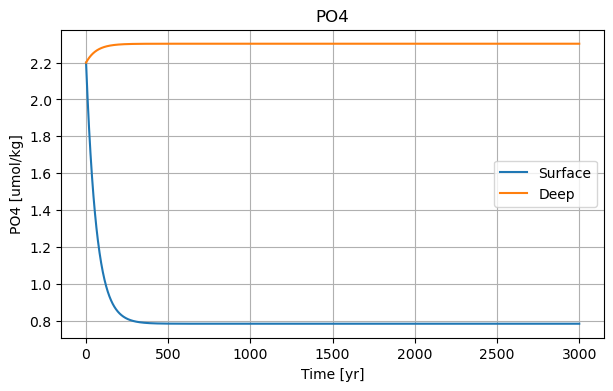

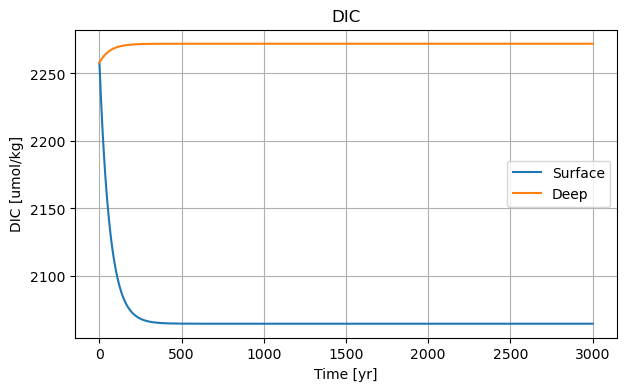

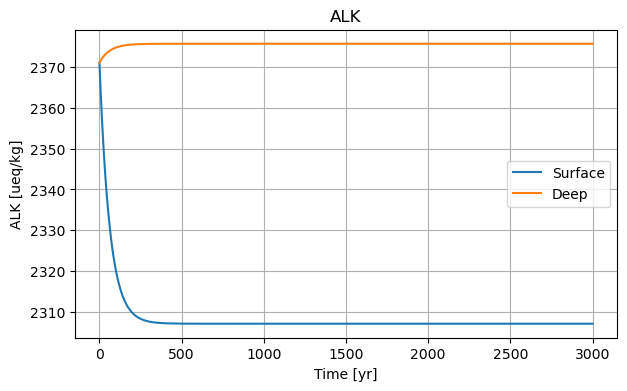

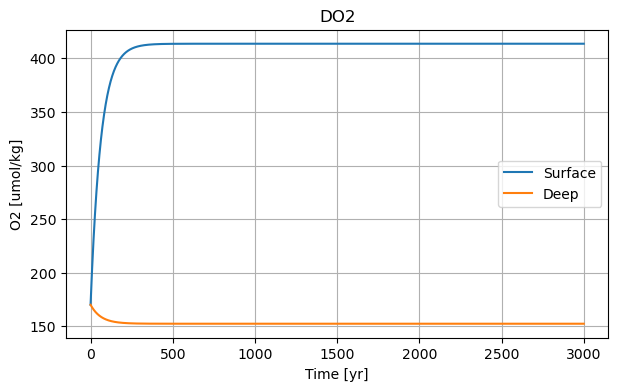

In [ ]:
for var, ylabel in [
    ("PO4", "PO4 [umol/kg]"),
    ("DIC", "DIC [umol/kg]"),
    ("ALK", "ALK [ueq/kg]"),
    ("DO2", "O2 [umol/kg]"),
]:
    plt.figure()
    plt.plot(hist["year"], hist[f"{var}S"], label="Surface")
    plt.plot(hist["year"], hist[f"{var}D"], label="Deep")
    plt.xlabel("Time [yr]")
    plt.ylabel(ylabel)
    plt.title(var)
    plt.legend()
    plt.grid(True)
    plt.show()

## 11. Challenge A: 鉛直交換を変える / Change vertical exchange

`FSD` は表層と深層の交換を表します。  
`FSD` represents exchange between the surface and deep boxes.

`FSD` を大きくすると、深層水がより強く表層へ供給されます。  
A larger `FSD` means stronger supply of deep water to the surface.

**予想 / Prediction**

`FSD` を大きくすると、表層 PO4 は増えるでしょうか、減るでしょうか。  
If `FSD` is increased, does surface PO4 increase or decrease?

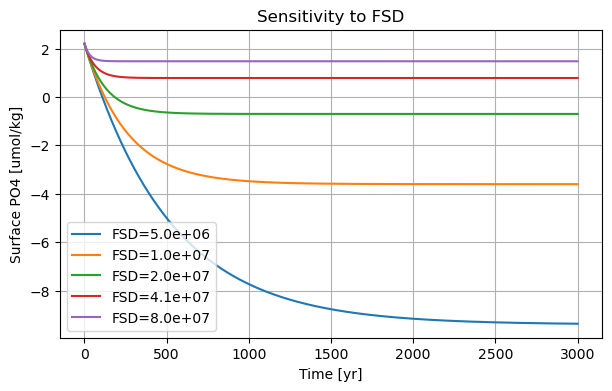

,FSD,Final PO4S,Final DICS,Final O2S
0,5000000.0,-9.371688,678.141073,2160.330469
1,10000000.0,-3.603112,1465.713273,1168.135327
2,20000000.0,-0.701581,1861.853391,669.072130
3,40960000.0,0.783213,2064.569327,413.687585
4,80000000.0,1.474605,2158.963771,294.768064


In [ ]:
FSD_list = [0.5e7, 1.0e7, 2.0e7, 4.096e7, 8.0e7]
summary = []

plt.figure()
for f in FSD_list:
    _, h = run_two_box(years=3000, FSD=f)
    plt.plot(h["year"], h["PO4S"], label=f"FSD={f:.1e}")
    summary.append({
        "FSD": f,
        "Final PO4S": h["PO4S"].iloc[-1],
        "Final DICS": h["DICS"].iloc[-1],
        "Final O2S": h["DO2S"].iloc[-1],
    })

plt.xlabel("Time [yr]")
plt.ylabel("Surface PO4 [umol/kg]")
plt.title("Sensitivity to FSD")
plt.legend()
plt.grid(True)
plt.show()

pd.DataFrame(summary)

## 12. Challenge B: 生物ポンプを変える / Change biological export

`CEPS` は表層から深層へ輸送される有機炭素の強さを表します。  
`CEPS` represents the strength of organic carbon export from the surface to the deep ocean.

**予想 / Prediction**

`CEPS` を大きくすると、表層 DIC と O2 はどうなるでしょうか。  
If `CEPS` is increased, what happens to surface DIC and O2?

実行後、なぜそうなったのかを自分の言葉で説明してください。  
After running the cell, explain the result in your own words.

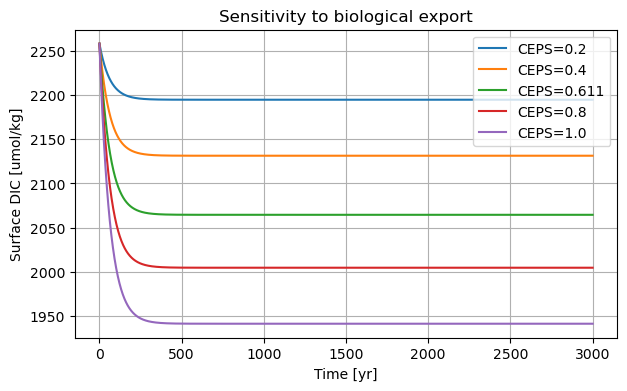

,CEPS,Final PO4S,Final DICS,Final O2S
0,0.200,1.736240,2194.684284,249.766832
1,0.400,1.272480,2131.368003,329.533622
2,0.611,0.783213,2064.569327,413.687585
3,0.800,0.344959,2004.735442,489.067201
4,1.000,-0.118801,1941.419161,568.833991


In [ ]:
CEPS_list = [0.2, 0.4, 0.611, 0.8, 1.0]
summary = []

plt.figure()
for c in CEPS_list:
    _, h = run_two_box(years=3000, CEPS=c)
    plt.plot(h["year"], h["DICS"], label=f"CEPS={c}")
    summary.append({
        "CEPS": c,
        "Final PO4S": h["PO4S"].iloc[-1],
        "Final DICS": h["DICS"].iloc[-1],
        "Final O2S": h["DO2S"].iloc[-1],
    })

plt.xlabel("Time [yr]")
plt.ylabel("Surface DIC [umol/kg]")
plt.title("Sensitivity to biological export")
plt.legend()
plt.grid(True)
plt.show()

pd.DataFrame(summary)

## 13. Challenge C: 大気海洋 CO2 交換を入れる / Turn on air-sea CO2 exchange

ここでは `air_sea=True` にします。  
Here we set `air_sea=True`.

表層海洋 pCO2 と大気 pCO2 の差に応じて、CO2 が交換されます。  
CO2 is exchanged according to the difference between surface-ocean pCO2 and atmospheric pCO2.

**見るべき点 / What to look at**

- 大気 pCO2 がどちらへ動くか。  
  In which direction atmospheric pCO2 changes.

- 表層 pCO2 と大気 pCO2 が近づくか。  
  Whether surface pCO2 and atmospheric pCO2 approach each other.

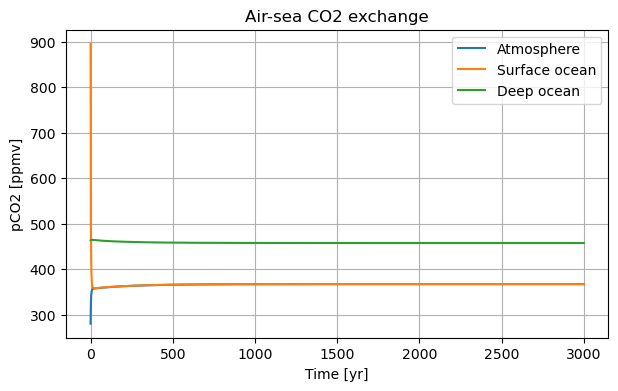

,year,PO4S,PO4D,DICS,DICD,ALKS,ALKD,DO2S,DO2D,PCO2S,PCO2D,PCO2A
2996,2996.0,0.783213,2.302607,2052.889262,2260.329152,2307.165791,2375.623615,413.687585,152.351785,367.137312,457.496524,367.137309
2997,2997.0,0.783213,2.302607,2052.889262,2260.329152,2307.165791,2375.623615,413.687585,152.351785,367.137312,457.496523,367.137309
2998,2998.0,0.783213,2.302607,2052.889262,2260.329152,2307.165791,2375.623615,413.687585,152.351785,367.137313,457.496523,367.137309
2999,2999.0,0.783213,2.302607,2052.889262,2260.329152,2307.165791,2375.623615,413.687585,152.351785,367.137313,457.496523,367.137310
3000,3000.0,0.783213,2.302607,2052.889262,2260.329152,2307.165791,2375.623615,413.687585,152.351785,367.137313,457.496523,367.137310


In [ ]:
final_air, hist_air = run_two_box(years=3000, air_sea=True)

plt.figure()
plt.plot(hist_air["year"], hist_air["PCO2A"], label="Atmosphere")
plt.plot(hist_air["year"], hist_air["PCO2S"], label="Surface ocean")
plt.plot(hist_air["year"], hist_air["PCO2D"], label="Deep ocean")
plt.xlabel("Time [yr]")
plt.ylabel("pCO2 [ppmv]")
plt.title("Air-sea CO2 exchange")
plt.legend()
plt.grid(True)
plt.show()

hist_air.tail()

## 14. 自分で実験する / Your own experiment

ここは自由に値を変えるセルです。  
This is a free experiment cell.

まずは次を変えてみてください。  
Try changing these first:

```python
my_FSD
my_CEPS
my_air_sea
```

**おすすめ / Suggested experiments**

1. `my_FSD = 1.0e7`  
2. `my_FSD = 8.0e7`  
3. `my_CEPS = 0.2`  
4. `my_CEPS = 1.0`  
5. `my_air_sea = False`

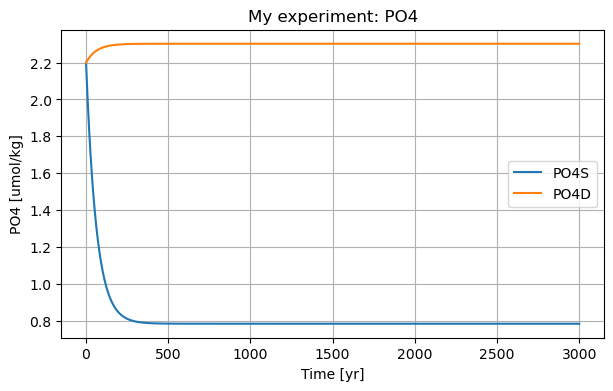

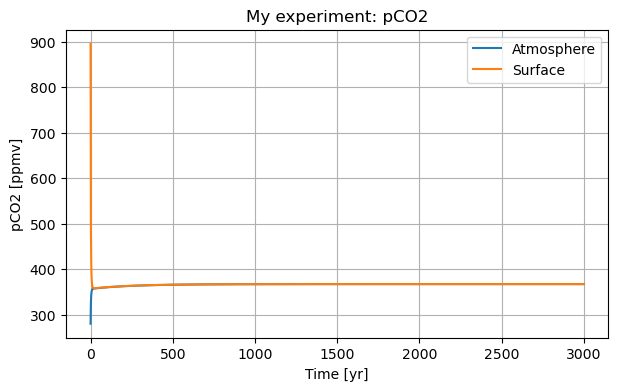

In [ ]:
my_FSD = 4.096e7
my_CEPS = 0.611
my_air_sea = True

final_my, hist_my = run_two_box(
    years=3000,
    FSD=my_FSD,
    CEPS=my_CEPS,
    air_sea=my_air_sea,
)

plt.figure()
plt.plot(hist_my["year"], hist_my["PO4S"], label="PO4S")
plt.plot(hist_my["year"], hist_my["PO4D"], label="PO4D")
plt.xlabel("Time [yr]")
plt.ylabel("PO4 [umol/kg]")
plt.title("My experiment: PO4")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(hist_my["year"], hist_my["PCO2A"], label="Atmosphere")
plt.plot(hist_my["year"], hist_my["PCO2S"], label="Surface")
plt.xlabel("Time [yr]")
plt.ylabel("pCO2 [ppmv]")
plt.title("My experiment: pCO2")
plt.legend()
plt.grid(True)
plt.show()

## 15. 課題 / Exercises

### 課題 1 / Exercise 1

`FSD` を小さくすると、表層 PO4 はどう変化するか。  
What happens to surface PO4 when `FSD` is reduced?

### 課題 2 / Exercise 2

`CEPS` を大きくすると、表層 DIC と O2 はどう変化するか。  
What happens to surface DIC and O2 when `CEPS` is increased?

### 課題 3 / Exercise 3

`air_sea=True` と `air_sea=False` で、大気 pCO2 の振る舞いはどう違うか。  
How does atmospheric pCO2 behave differently between `air_sea=True` and `air_sea=False`?

### 課題 4 / Exercise 4

この 2-box モデルで表現できない海洋過程を 3 つ挙げよ。  
List three ocean processes that cannot be represented by this 2-box model.